<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/TradingStrategies/TradingStrategies/Strategy_Performance_Attribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

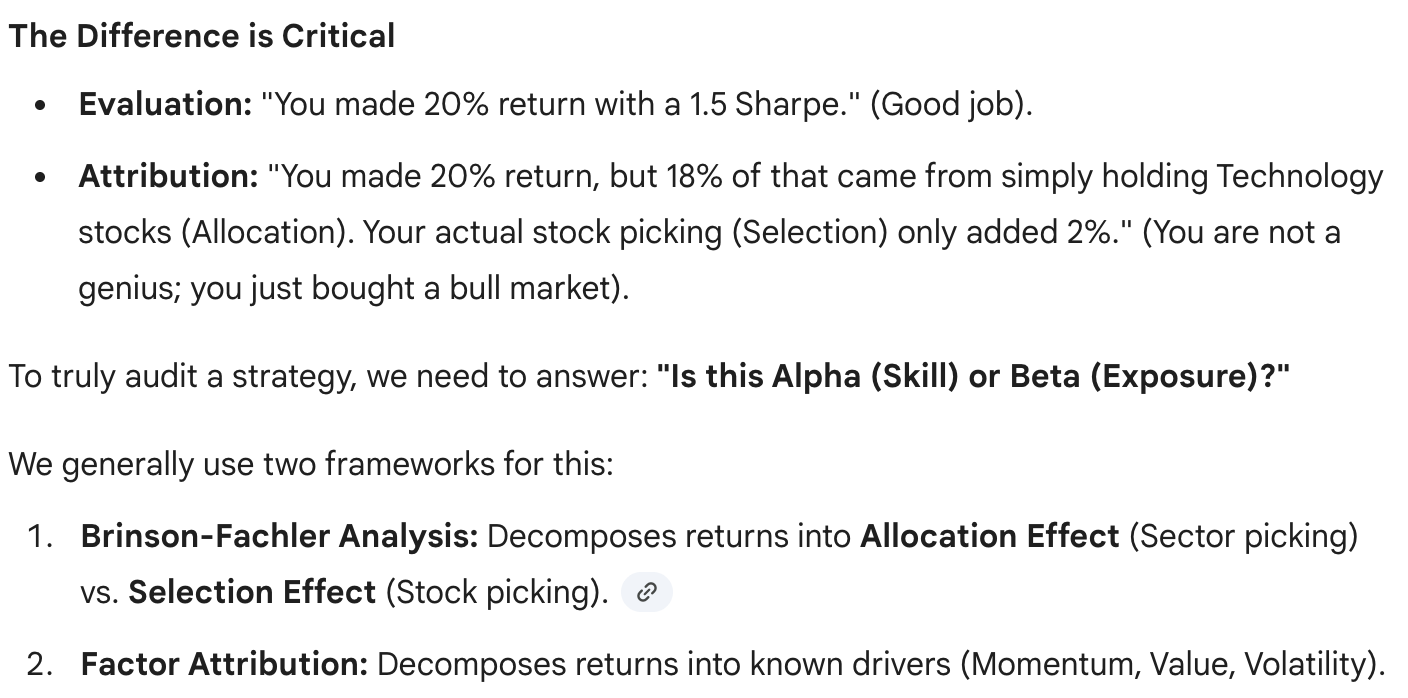

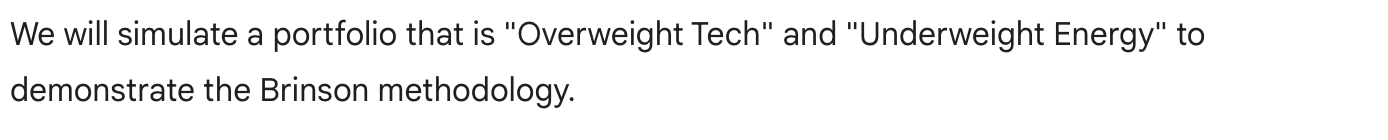

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
# --- 1. CONFIGURATION ---
# We define a "Universe" of sectors
assets = {
    'XLK': 'Technology',
    'XLE': 'Energy',
    'XLF': 'Financials',
    'XLV': 'Healthcare'
}
tickers = list(assets.keys())
benchmark_ticker = 'SPY'

start_date = '2023-01-01'
end_date = '2024-01-01'

In [5]:
# Download Data
data = yf.download(tickers + [benchmark_ticker], start=start_date, end=end_date, progress=False, auto_adjust=False)['Adj Close']

# Calculate Returns
returns = data.pct_change().dropna()
returns.head()

Ticker,SPY,XLE,XLF,XLK,XLV
Date,,,,,
2023-01-04,0.007720,-0.000119,0.016026,0.002596,0.002658
2023-01-05,-0.011414,0.018249,-0.007456,-0.019421,-0.010234
2023-01-06,0.022932,0.018969,0.022248,0.029295,0.009224
2023-01-09,-0.000567,-0.003540,-0.003674,0.011625,-0.016732
2023-01-10,0.007013,0.007106,0.005674,0.006182,0.008396


In [6]:
# --- 2. DEFINE WEIGHTS (The "Active" Decision) ---
# Benchmark Weights (Approximate S&P 500 weights for 2023)
bench_weights = pd.Series({
    'XLK': 0.30,
    'XLE': 0.05,
    'XLF': 0.10,
    'XLV': 0.15
})
# Normalize benchmark to sum to 1.0 (assuming these 4 represent our whole universe for simplicity)
bench_weights = bench_weights / bench_weights.sum()
bench_weights

,0
XLK,0.500000
XLE,0.083333
XLF,0.166667
XLV,0.250000


In [7]:
# Portfolio Weights (Our "Active Bets")
# We bet HEAVY on Tech (XLK) and ignored Energy (XLE)
port_weights = pd.Series({
    'XLK': 0.60, # Overweight Tech
    'XLE': 0.00, # Underweight Energy
    'XLF': 0.10, # Neutral
    'XLV': 0.30  # Overweight Healthcare
})
port_weights = port_weights / port_weights.sum()

print("📊 Weights Defined.")

📊 Weights Defined.


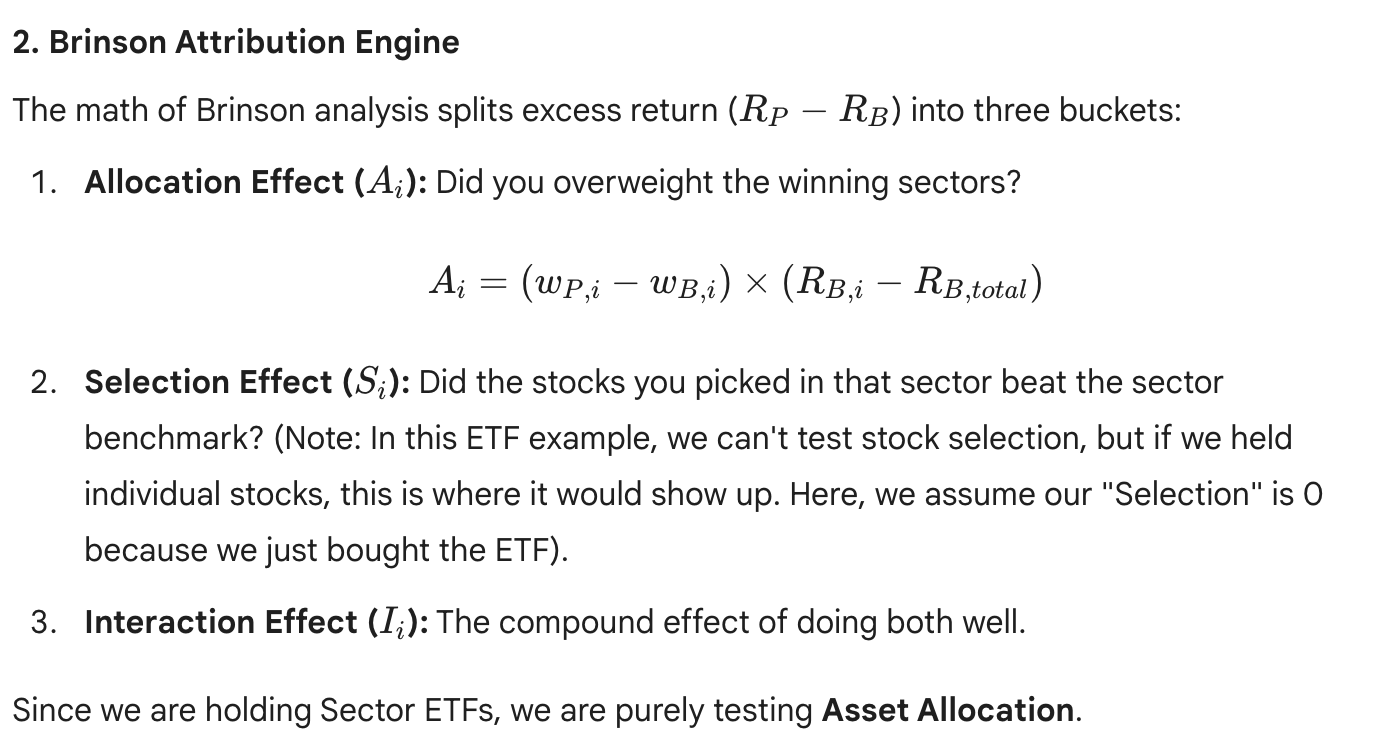

In [9]:
# --- CALCULATE TOTAL RETURNS ---
# Cumulative Return for each Sector over the period
sector_returns = (1 + returns[tickers]).prod() - 1
benchmark_return = (1 + returns[benchmark_ticker]).prod() - 1

# --- BRINSON CALCULATION ---
attribution = pd.DataFrame(index=tickers)
attribution.head()

""
XLK
XLE
XLF
XLV


In [10]:
# 1. Allocation Effect
# (Port Weight - Bench Weight) * (Sector Return - Total Benchmark Return)
# Logic: If I overweight a sector (W_p > W_b) that beats the market (R_s > R_b), I add value.
attribution['Allocation'] = (port_weights - bench_weights) * (sector_returns - benchmark_return.item())

# 2. Selection Effect
# (Port Weight) * (Portfolio Sector Return - Benchmark Sector Return)
# NOTE: Since we bought the Sector ETFs directly, our return MATCHES the benchmark sector return.
# So Selection Effect is ZERO in this specific ETF example.
# If we bought specific stocks, we would use: (port_weights) * (my_stocks_return - sector_etf_return)
attribution['Selection'] = 0.0

# 3. Total Active Return Contribution
attribution['Total_Effect'] = attribution['Allocation'] + attribution['Selection']

# --- SUMMARY ---
print(f"📈 Benchmark Return: {benchmark_return.item()*100:.2f}%")

📈 Benchmark Return: 26.71%


🚀 Portfolio Return: 36.38%
⚡ Active Return (Alpha): 9.67%

🏆 ATTRIBUTION BY SECTOR:
     Allocation  Selection  Total_Effect
XLK        3.08        0.0          3.08
XLE        1.98        0.0          1.98
XLF        1.00        0.0          1.00
XLV       -1.22        0.0         -1.22


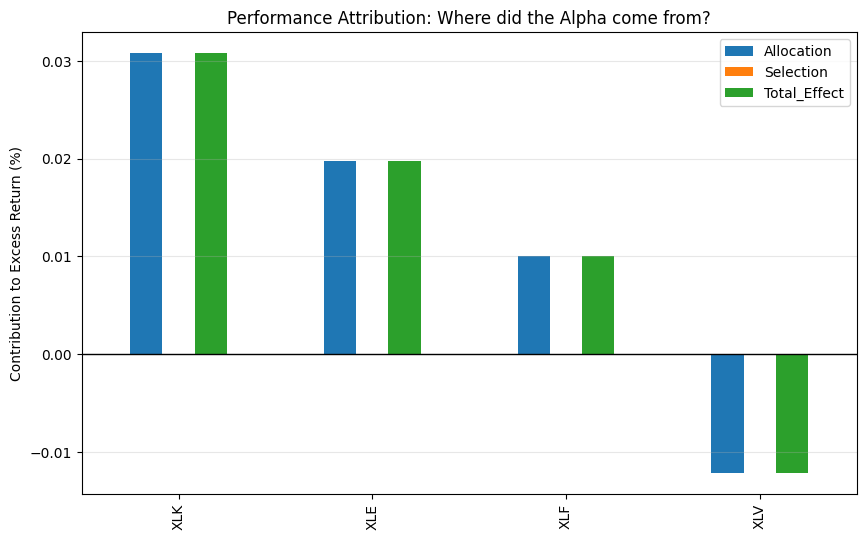

In [11]:
# Calculate Portfolio Return manually
port_return = (port_weights * sector_returns).sum()
print(f"🚀 Portfolio Return: {port_return*100:.2f}%")

active_return = port_return - benchmark_return.item()
print(f"⚡ Active Return (Alpha): {active_return*100:.2f}%")

print("\n🏆 ATTRIBUTION BY SECTOR:")
print(attribution.round(4) * 100)

# --- VISUALIZATION ---
attribution.plot(kind='bar', figsize=(10, 6))
plt.title("Performance Attribution: Where did the Alpha come from?")
plt.ylabel("Contribution to Excess Return (%)")
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.show()

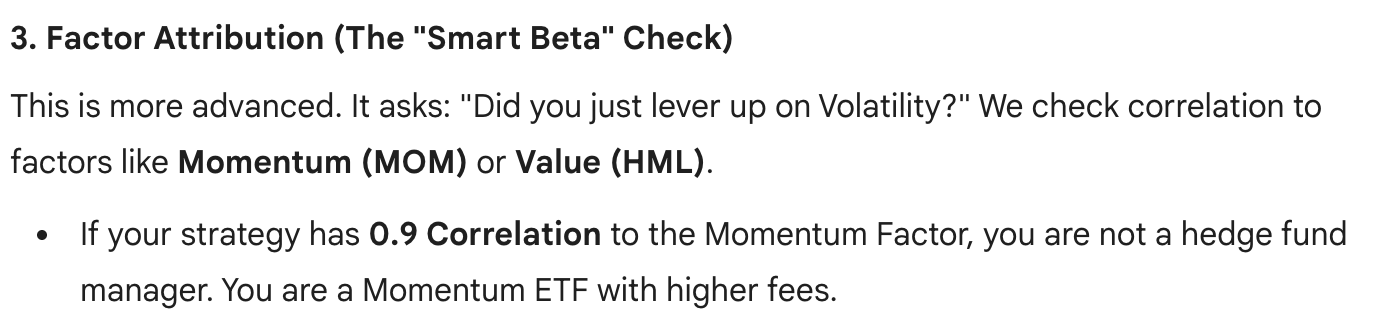

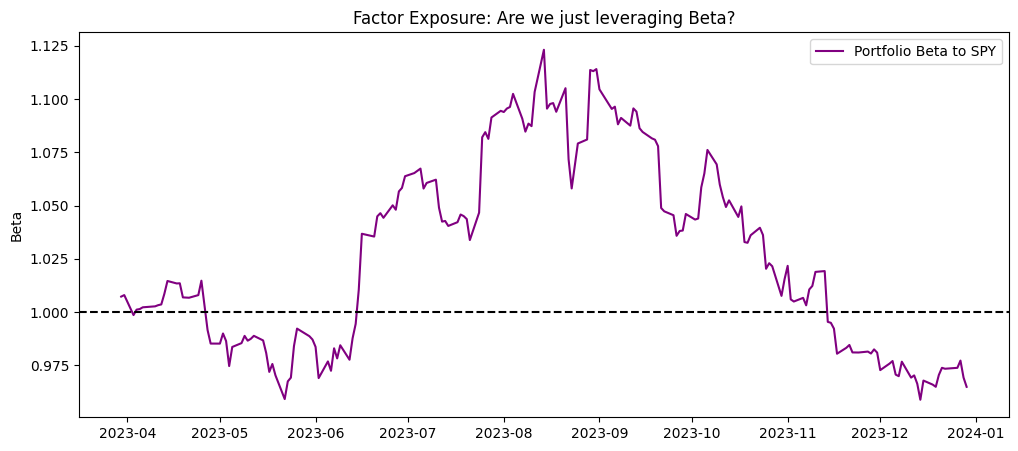

In [12]:
# Simple Rolling Beta check against a Factor (e.g., Tech/Growth as a proxy)
# In a real rigorous setting, we would download Fama-French Data.

window = 60
port_daily_ret = (returns[tickers] * port_weights).sum(axis=1)
bench_daily_ret = returns[benchmark_ticker]

# Calculate Rolling Beta
rolling_cov = port_daily_ret.rolling(window).cov(bench_daily_ret)
rolling_var = bench_daily_ret.rolling(window).var()
rolling_beta = rolling_cov / rolling_var

plt.figure(figsize=(12, 5))
plt.plot(rolling_beta, color='purple', label='Portfolio Beta to SPY')
plt.axhline(1.0, color='black', linestyle='--')
plt.title("Factor Exposure: Are we just leveraging Beta?")
plt.ylabel("Beta")
plt.legend()
plt.show()